# False alarm rate simulation

Empirical false alarm rate of the `CUSUM` detector under the null (i.i.d. standard normal data) as a function of stream length. The threshold is calibrated to a target false alarm probability over a stream of length $T$, and we verify that the realized false alarm rate stays controlled as the stream grows way beyond this point.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from gridcp import GridDetector
from gridcp.calibration import (
    calibrate_threshold_false_alarm,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import CUSUM

## Calibrate threshold

In [ ]:
from gridcp.calibration import calibrate_threshold_false_alarm

score = CUSUM(n_features = 1, enable_penalty = True)
start_time = time.perf_counter()
threshold = calibrate_threshold_false_alarm(
    score,
    false_alarm_probability = 0.05,
    n_paths = 20_000,
    stream_len = 100,
    pre_sampler = lambda rng: rng.standard_normal(),
    rng = 0,
)
print(f"Calibration done in {time.perf_counter() - start_time:.1f}s. Threshold: {threshold[0]:.4f}")

detector = GridDetector(score=score, threshold=threshold)

Calibration done in 2.6s. Threshold: 3.0194


## Simulate alarm times under the null

In [ ]:
# Takes approx. 20 minutes on a MacBook pro
t0 = time.perf_counter()
alarm_times = mc_alarm_times(
    detector, 
    n_paths = 100_000, 
    stream_len = 10_000, 
    pre_sampler=lambda rng: rng.standard_normal(), 
    rng=1, 
    n_jobs=18) # must set 18 jobs for reproducibility
print(f"Simulation finished in {time.perf_counter()-t0:.1f}s")

Simulation finished in 1207.7s


## False alarm rate over the stream length

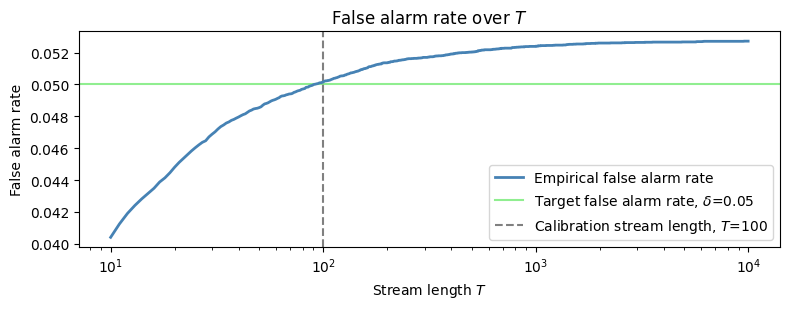

In [17]:
Ts = np.geomspace(10, 10_000, 5_000).astype(int)
at_sorted = np.sort(alarm_times)
false_alarm_rates = np.searchsorted(at_sorted, Ts) / 100_000

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(
    Ts[:-1],
    false_alarm_rates[:-1],
    color="steelblue",
    linewidth=2,
    label="Empirical false alarm rate",
)
ax.axhline(
    0.05,
    color="lightgreen",
    label=rf"Target false alarm rate, $\delta$={0.05}",
    zorder=1
)
ax.axvline(
    100,
    color="gray",
    linestyle="--",
    label=f"Calibration stream length, $T$={100}",
    zorder=1
)
ax.set_xscale("log")
ax.set_xlabel("Stream length $T$")
ax.set_ylabel("False alarm rate")
ax.set_title("False alarm rate over $T$")
ax.legend()
plt.tight_layout()
plt.savefig("fa_rate.pdf", bbox_inches="tight")
plt.show()